In [2]:
!pip install gymnasium[mujoco] imageio

In [3]:
!apt-get install -y libglfw3 libglew2.2 libgl1-mesa-glx libosmesa6 2>/dev/null

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libgl1-mesa-glx is already the newest version (23.0.4-0ubuntu1~22.04.1).
Suggested packages:
  glew-utils libgles1 libvulkan1
The following NEW packages will be installed:
  libglew2.2 libglfw3 libosmesa6
0 upgraded, 3 newly installed, 0 to remove and 3 not upgraded.
Need to get 3,115 kB/3,394 kB of archives.
After this operation, 13.8 MB of additional disk space will be used.
Err:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 libosmesa6 amd64 23.2.1-1ubuntu3.1~22.04.3
  404  Not Found [IP: 91.189.92.23 80]


In [4]:
import os
os.environ["MUJOCO_GL"] = "egl"

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import imageio

In [5]:
env = gym.make("Walker2d-v5", render_mode="rgb_array")
print("Environment created:", env.spec.id)

Environment created: Walker2d-v5


In [6]:
print("Observation Space:", env.observation_space)
print("Observation Shape:", env.observation_space.shape)
print("Observation Low:", env.observation_space.low)
print("Observation High:", env.observation_space.high)

print("\nAction Space:", env.action_space)
print("Action Shape:", env.action_space.shape)
print("Action Low:", env.action_space.low)
print("Action High:", env.action_space.high)

Observation Space: Box(-inf, inf, (17,), float64)
Observation Shape: (17,)
Observation Low: [-inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf -inf
 -inf -inf -inf]
Observation High: [inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf inf]

Action Space: Box(-1.0, 1.0, (6,), float32)
Action Shape: (6,)
Action Low: [-1. -1. -1. -1. -1. -1.]
Action High: [1. 1. 1. 1. 1. 1.]


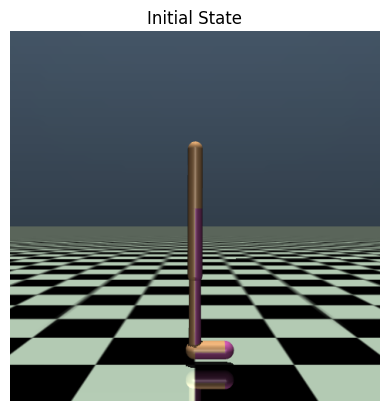

In [7]:
observation, info = env.reset(seed=42)
frame = env.render()
plt.imshow(frame)
plt.axis("off")
plt.title("Initial State")
plt.show()

In [11]:
import pandas as pd

env = gym.make("Walker2d-v5", render_mode="rgb_array")

frames = []
reward_log = []  # will hold per-step reward details

num_episodes_to_string_together = 5  # increase this for a longer GIF

for ep in range(num_episodes_to_string_together):
    observation, info = env.reset(seed=ep)
    episode_over = False
    step_count = 0
    total_reward = 0

    while not episode_over:
        action = env.action_space.sample()
        observation, reward, terminated, truncated, info = env.step(action)

        frames.append(env.render())

        reward_log.append({
            "episode": ep + 1,
            "step": step_count,
            "reward": reward,
            "reward_forward": info.get("reward_forward", None),
            "reward_ctrl": info.get("reward_ctrl", None),
            "reward_survive": info.get("reward_survive", None),
            "x_position": info.get("x_position", None),
        })

        total_reward += reward
        step_count += 1
        episode_over = terminated or truncated

    print(f"Episode {ep+1}: {step_count} steps, total reward = {total_reward:.2f}")

env.close()

# Turn the reward log into a DataFrame so you can inspect/export it
reward_df = pd.DataFrame(reward_log)
print(f"\nTotal frames collected: {len(frames)}")
reward_df.head(20)

Episode 1: 12 steps, total reward = -0.19
Episode 2: 14 steps, total reward = -1.90
Episode 3: 24 steps, total reward = 3.13
Episode 4: 23 steps, total reward = 5.93
Episode 5: 14 steps, total reward = -4.26

Total frames collected: 87


,episode,step,reward,reward_forward,reward_ctrl,reward_survive,x_position
0,1,0,0.576050,-0.421050,-0.002901,1.0,-0.001999
1,1,1,-0.132782,-1.131402,-0.001381,1.0,-0.011050
2,1,2,-0.228158,-1.225973,-0.002185,1.0,-0.020858
3,1,3,-0.087638,-1.085495,-0.002143,1.0,-0.029542
4,1,4,0.037088,-0.960583,-0.002328,1.0,-0.037226
5,1,5,0.063902,-0.934398,-0.001701,1.0,-0.044702
6,1,6,-0.006342,-1.003731,-0.002611,1.0,-0.052731
7,1,7,0.121602,-0.877214,-0.001184,1.0,-0.059749
8,1,8,0.153772,-0.844472,-0.001756,1.0,-0.066505
9,1,9,0.105754,-0.891860,-0.002387,1.0,-0.073640


In [12]:
# fps lower = slower playback = feels longer even with same frame count
imageio.mimsave("walker2d_random.gif", frames, fps=15)
print(f"Saved walker2d_random.gif with {len(frames)} frames")

Saved walker2d_random.gif with 87 frames


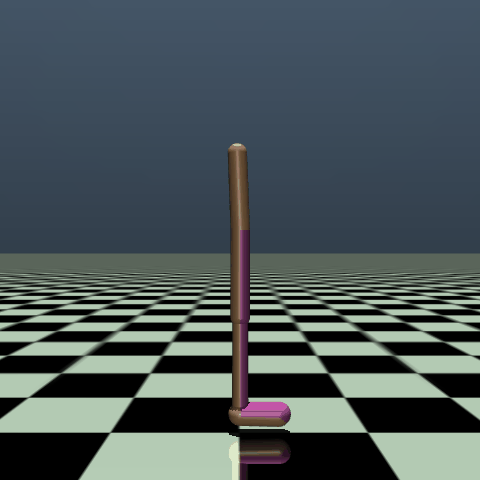

In [13]:
from IPython.display import Image
Image("walker2d_random.gif")

In [14]:
reward_df.to_csv("walker2d_rewards.csv", index=False)
print("Saved walker2d_rewards.csv")

Saved walker2d_rewards.csv


In [15]:
print("Reward component averages across all steps:")
print(reward_df[["reward", "reward_forward", "reward_ctrl", "reward_survive"]].mean())

Reward component averages across all steps:
reward            0.031114
reward_forward   -0.909371
reward_ctrl      -0.002043
reward_survive    0.942529
dtype: float64
